# Ridge Notebook

이 노트북은 `Ridge` 회귀를 **생산(Production) / 소비(Consumption)**로 분리 학습하고,
아래 결과를 함께 확인합니다.

- 생산/소비/전체 MAE
- Rolling feature별 MAE (생산/소비/전체)
- Lag feature별 MAE (생산/소비/전체)
- 잔차(Residual) 분석 시각화
- Ridge 계수 기반 Feature Importance 시각화

In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
sns.set_theme(style="white")
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

COLOR_PROD = "#4C78A8"
COLOR_CONS = "#F58518"
COLOR_OVERALL = "#54A24B"
COLOR_ACTUAL = "#2F2F2F"
COLOR_PRED = "#E45756"

In [14]:
ROOT_DIR = Path.cwd().parent

NB_DIR = ROOT_DIR / "notebooks"
DATA_DIR = ROOT_DIR / "data" / "processed_data"
FIG_DIR = NB_DIR / "Rigde_codex_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PARQUET_PATH = DATA_DIR / "train_processed.parquet"
VALID_PARQUET_PATH = DATA_DIR / "valid_processed.parquet"
TRAIN_CSV_PATH = DATA_DIR / "train_processed.csv"
VALID_CSV_PATH = DATA_DIR / "valid_processed.csv"

TARGET_COL = "target"
SPLIT_COL = "is_consumption"

LAG_COLS = ["lag_1", "lag_24", "lag_48", "lag_168"]
ROLLING_COLS = [
    "rolling_mean_3", "rolling_std_3",
    "rolling_mean_24", "rolling_std_24",
    "rolling_mean_48", "rolling_std_48",
    "rolling_mean_168", "rolling_std_168",
]


In [15]:
def load_processed_df(primary_path: Path, fallback_path: Path) -> pd.DataFrame:
    if primary_path.exists():
        if primary_path.suffix == ".parquet":
            df = pd.read_parquet(primary_path)
        else:
            df = pd.read_csv(primary_path, parse_dates=["datetime", "date"])
        src = primary_path.name
    elif fallback_path.exists():
        if fallback_path.suffix == ".parquet":
            df = pd.read_parquet(fallback_path)
        else:
            df = pd.read_csv(fallback_path, parse_dates=["datetime", "date"])
        src = fallback_path.name
    else:
        raise FileNotFoundError(f"No processed file found: {primary_path} or {fallback_path}")

    for col in ["datetime", "date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    print(f"loaded: {src} -> {df.shape}")
    return df


# train/valid 모두 parquet 우선
train_df = load_processed_df(TRAIN_PARQUET_PATH, TRAIN_CSV_PATH)
valid_df = load_processed_df(VALID_PARQUET_PATH, VALID_CSV_PATH)

tr_prod = train_df[train_df[SPLIT_COL] == 0].copy()
tr_cons = train_df[train_df[SPLIT_COL] == 1].copy()
va_prod = valid_df[valid_df[SPLIT_COL] == 0].copy()
va_cons = valid_df[valid_df[SPLIT_COL] == 1].copy()

print("train production:", tr_prod.shape)
print("train consumption:", tr_cons.shape)
print("valid production:", va_prod.shape)
print("valid consumption:", va_cons.shape)


loaded: train_processed.parquet -> (1614612, 123)
loaded: valid_processed.parquet -> (403740, 123)
train production: (807306, 123)
train consumption: (807306, 123)
valid production: (201870, 123)
valid consumption: (201870, 123)


In [16]:
DROP_COLUMNS = {
    "row_id", "datetime", "date", "data_block_id", TARGET_COL, SPLIT_COL,
}


def get_features(df: pd.DataFrame) -> list[str]:
    cols = [c for c in df.columns if c not in DROP_COLUMNS]
    return cols


def build_xy(df: pd.DataFrame, feature_cols: list[str]):
    x = df[feature_cols].copy()
    x = x.fillna(0)
    y = df[TARGET_COL].copy()
    return x, y

In [17]:
def train_segment(tr_df: pd.DataFrame, va_df: pd.DataFrame, seg_name: str):
    feat_tr = get_features(tr_df)
    feat_va = set(get_features(va_df))

    # train/valid 컬럼이 다를 수 있으므로 공통 피처만 사용
    feat_cols = [c for c in feat_tr if c in feat_va]

    missing_in_valid = [c for c in feat_tr if c not in feat_va]
    if missing_in_valid:
        preview = ", ".join(missing_in_valid[:8])
        print(f"[{seg_name}] dropped {len(missing_in_valid)} train-only features (e.g., {preview})")

    if len(feat_cols) == 0:
        raise ValueError(f"[{seg_name}] No common feature columns between train and valid")

    x_tr, y_tr = build_xy(tr_df, feat_cols)
    x_va, y_va = build_xy(va_df, feat_cols)

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0, random_state=42),
    )
    model.fit(x_tr, y_tr)

    pred = np.clip(model.predict(x_va), 0, None)
    mae = mean_absolute_error(y_va, pred)

    va_out = va_df.copy()
    va_out["pred_ridge"] = pred
    va_out["abs_error"] = np.abs(va_out[TARGET_COL] - va_out["pred_ridge"])

    ridge_model = model.named_steps["ridge"]
    coef = pd.Series(ridge_model.coef_, index=feat_cols)

    print(f"[{seg_name}] MAE={mae:.4f}, n_features={len(feat_cols)}")

    return {
        "segment": seg_name,
        "model": model,
        "coef": coef,
        "features": feat_cols,
        "y_valid": y_va,
        "pred": pred,
        "mae": mae,
        "valid_df": va_out,
    }


In [18]:
res_prod = train_segment(tr_prod, va_prod, "production")
res_cons = train_segment(tr_cons, va_cons, "consumption")
res_all = train_segment(train_df, valid_df, "overall")

[production] MAE=28.0375, n_features=117
[consumption] MAE=36.2917, n_features=117
[overall] MAE=32.5769, n_features=117


In [19]:
all_actual = np.concatenate([res_prod["y_valid"].values, res_cons["y_valid"].values])
all_pred_split = np.concatenate([res_prod["pred"], res_cons["pred"]])
overall_mae_split = mean_absolute_error(all_actual, all_pred_split)

mae_summary = pd.DataFrame(
    {
        "segment": ["production", "consumption", "overall(single)", "overall(split-ensemble)"],
        "mae": [res_prod["mae"], res_cons["mae"], res_all["mae"], overall_mae_split],
    }
)

display(mae_summary.style.format({"mae": "{:.4f}"}))

,segment,mae
0,production,28.0375
1,consumption,36.2917
2,overall(single),32.5769
3,overall(split-ensemble),32.1646


In [20]:
def rolling_feature_mae_table(df_prod: pd.DataFrame, df_cons: pd.DataFrame, rolling_cols: list[str]):
    rows = []
    for col in rolling_cols:
        if col not in df_prod.columns or col not in df_cons.columns:
            continue

        prod_tmp = df_prod[[TARGET_COL, col]].dropna()
        cons_tmp = df_cons[[TARGET_COL, col]].dropna()
        all_tmp = pd.concat([prod_tmp, cons_tmp], axis=0)

        if len(prod_tmp) == 0 or len(cons_tmp) == 0:
            continue

        rows.append(
            {
                "rolling_feature": col,
                "production": mean_absolute_error(prod_tmp[TARGET_COL], prod_tmp[col]),
                "consumption": mean_absolute_error(cons_tmp[TARGET_COL], cons_tmp[col]),
                "overall": mean_absolute_error(all_tmp[TARGET_COL], all_tmp[col]),
            }
        )

    return pd.DataFrame(rows)

In [21]:
def lag_mae_table(df_prod: pd.DataFrame, df_cons: pd.DataFrame, lag_cols: list[str]):
    rows = []
    for lag_col in lag_cols:
        if lag_col not in df_prod.columns or lag_col not in df_cons.columns:
            continue

        prod_tmp = df_prod[[TARGET_COL, lag_col]].dropna()
        cons_tmp = df_cons[[TARGET_COL, lag_col]].dropna()
        all_tmp = pd.concat([prod_tmp, cons_tmp], axis=0)

        if len(prod_tmp) == 0 or len(cons_tmp) == 0:
            continue

        rows.append(
            {
                "lag": lag_col,
                "production": mean_absolute_error(prod_tmp[TARGET_COL], prod_tmp[lag_col]),
                "consumption": mean_absolute_error(cons_tmp[TARGET_COL], cons_tmp[lag_col]),
                "overall": mean_absolute_error(all_tmp[TARGET_COL], all_tmp[lag_col]),
            }
        )

    return pd.DataFrame(rows)

In [22]:
rolling_mae_df = rolling_feature_mae_table(va_prod, va_cons, ROLLING_COLS)
print("Rolling feature-wise MAE")
display(rolling_mae_df.style.format({"production": "{:.4f}", "consumption": "{:.4f}", "overall": "{:.4f}"}))

Rolling feature-wise MAE


,rolling_feature,production,consumption,overall
0,rolling_mean_3,87.8073,67.7356,77.7715
1,rolling_std_3,134.5794,479.6865,307.1330
2,rolling_mean_24,174.6187,117.8107,146.2147
3,rolling_std_24,190.9107,399.6130,295.2618
4,rolling_mean_48,176.3673,127.6249,151.9961
5,rolling_std_48,198.0975,390.2589,294.1782
6,rolling_mean_168,176.0502,133.7359,154.8930
7,rolling_std_168,204.7314,371.5375,288.1344


In [23]:
lag_mae_df = lag_mae_table(va_prod, va_cons, LAG_COLS)
print("Lag-wise MAE")
display(lag_mae_df.style.format({"production": "{:.4f}", "consumption": "{:.4f}", "overall": "{:.4f}"}))

Lag-wise MAE


,lag,production,consumption,overall
0,lag_1,48.3129,42.8199,45.5664
1,lag_24,64.2330,87.7994,76.0162
2,lag_48,80.4943,128.4441,104.4692
3,lag_168,81.6616,87.0544,84.3580


In [24]:
figures = []
figure_names = []

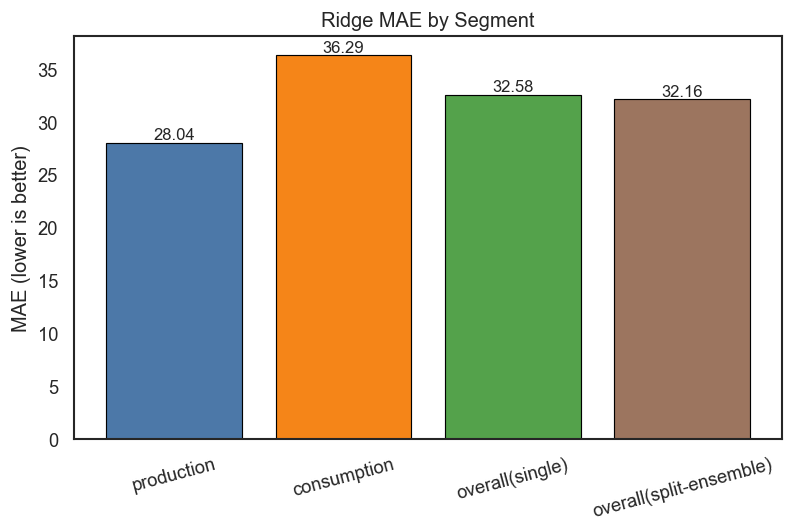

In [25]:
# 1) Ridge MAE Summary
fig1, ax1 = plt.subplots(figsize=(6.8, 4.6))
ax1.bar(
    mae_summary["segment"],
    mae_summary["mae"],
    color=[COLOR_PROD, COLOR_CONS, COLOR_OVERALL, "#9C755F"],
    edgecolor="black",
    linewidth=0.7,
)
for x, y in zip(mae_summary["segment"], mae_summary["mae"]):
    ax1.text(x, y, f"{y:.2f}", ha="center", va="bottom", fontsize=10)
ax1.set_title("Ridge MAE by Segment")
ax1.set_ylabel("MAE (lower is better)")
ax1.tick_params(axis="x", rotation=15)
plt.tight_layout()
figures.append(fig1)
figure_names.append("01_ridge_mae_summary.jpg")
plt.show()

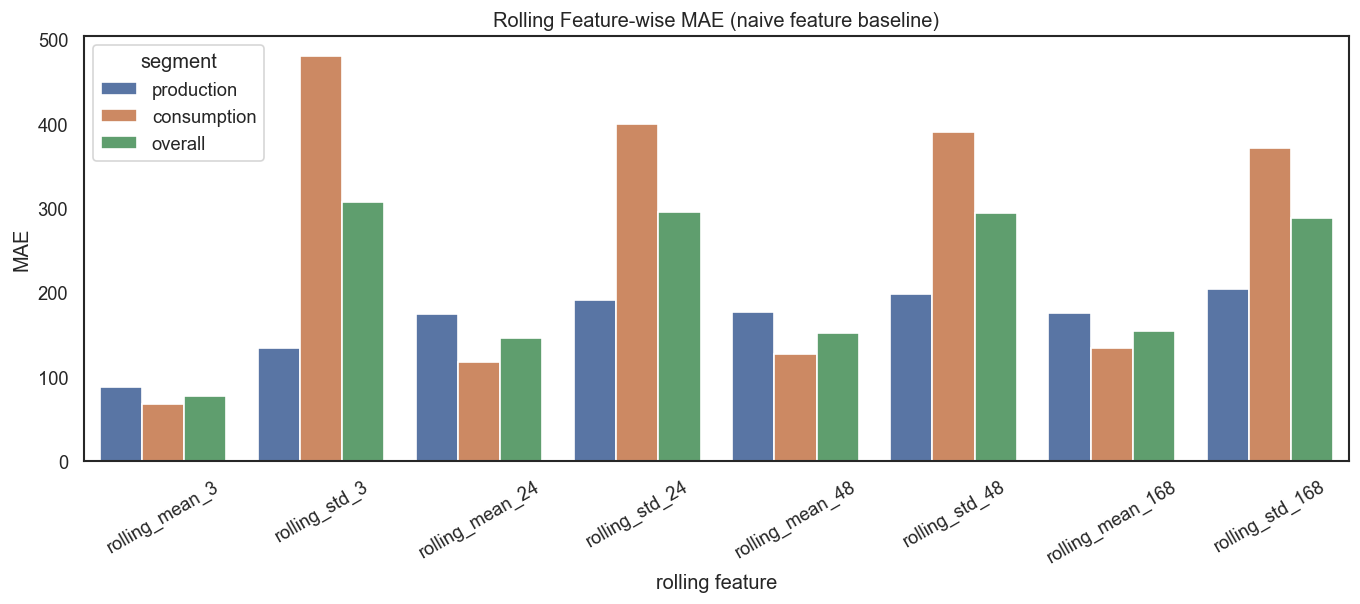

In [26]:
# 2) Rolling Feature-wise MAE
if not rolling_mae_df.empty:
    plot_roll = rolling_mae_df.melt(id_vars="rolling_feature", var_name="segment", value_name="mae")
    fig2, ax2 = plt.subplots(figsize=(11.5, 5.2))
    sns.barplot(data=plot_roll, x="rolling_feature", y="mae", hue="segment", ax=ax2)
    ax2.set_title("Rolling Feature-wise MAE (naive feature baseline)")
    ax2.set_xlabel("rolling feature")
    ax2.set_ylabel("MAE")
    ax2.tick_params(axis="x", rotation=30)
    ax2.legend(title="segment")
    plt.tight_layout()
    figures.append(fig2)
    figure_names.append("02_rolling_feature_mae.jpg")
    plt.show()

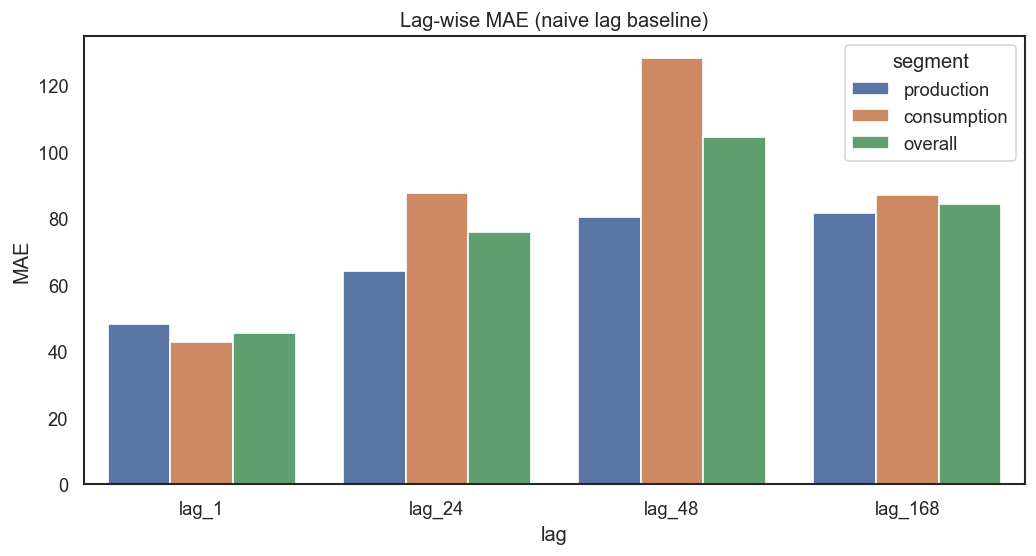

In [27]:
# 3) Lag-wise MAE
if not lag_mae_df.empty:
    plot_lag = lag_mae_df.melt(id_vars="lag", var_name="segment", value_name="mae")
    fig3, ax3 = plt.subplots(figsize=(8.8, 4.8))
    sns.barplot(data=plot_lag, x="lag", y="mae", hue="segment", ax=ax3)
    ax3.set_title("Lag-wise MAE (naive lag baseline)")
    ax3.set_xlabel("lag")
    ax3.set_ylabel("MAE")
    ax3.legend(title="segment")
    plt.tight_layout()
    figures.append(fig3)
    figure_names.append("03_lag_mae.jpg")
    plt.show()

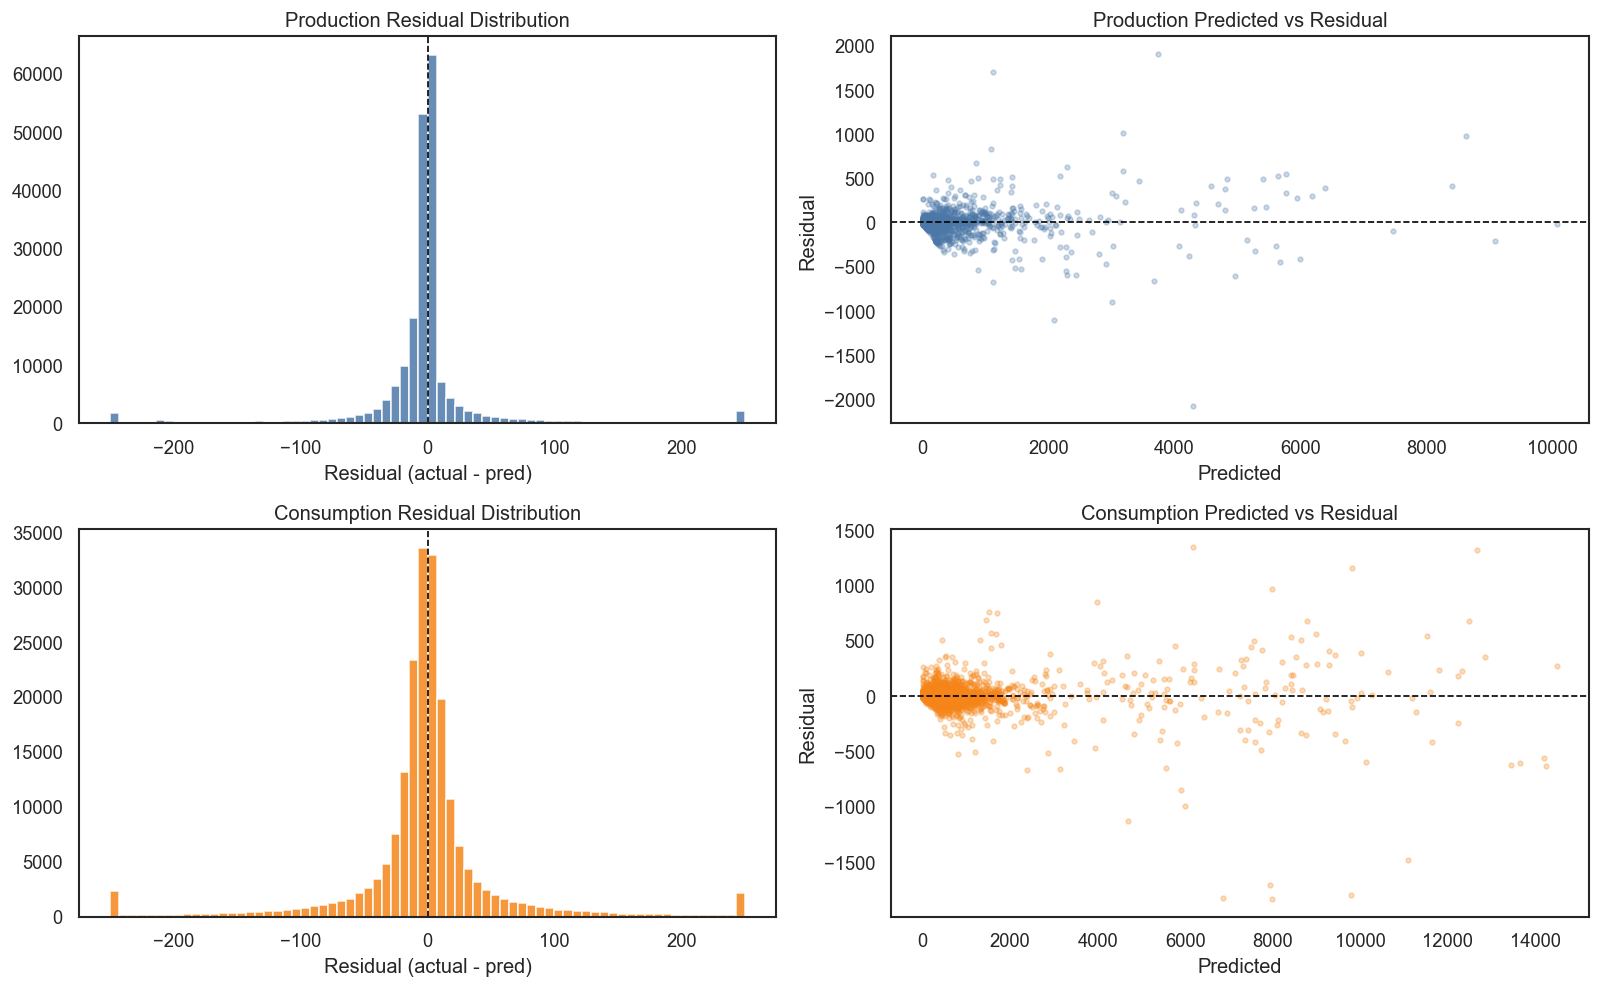

In [28]:
# 4) Residual Analysis (Ridge)
fig4, axes = plt.subplots(2, 2, figsize=(13.5, 8.4))

for r, (seg, res, color) in enumerate([
    ("Production", res_prod, COLOR_PROD),
    ("Consumption", res_cons, COLOR_CONS),
]):
    y_true = res["y_valid"].values
    y_pred = res["pred"]
    residual = y_true - y_pred

    axes[r, 0].hist(np.clip(residual, -250, 250), bins=70, color=color, alpha=0.85, edgecolor="white")
    axes[r, 0].axvline(0, color="black", linestyle="--", linewidth=1)
    axes[r, 0].set_title(f"{seg} Residual Distribution")
    axes[r, 0].set_xlabel("Residual (actual - pred)")

    n = min(5000, len(y_pred))
    idx = np.random.choice(len(y_pred), n, replace=False)
    axes[r, 1].scatter(y_pred[idx], residual[idx], s=8, alpha=0.28, color=color)
    axes[r, 1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[r, 1].set_title(f"{seg} Predicted vs Residual")
    axes[r, 1].set_xlabel("Predicted")
    axes[r, 1].set_ylabel("Residual")

plt.tight_layout()
figures.append(fig4)
figure_names.append("04_residual_analysis_ridge.jpg")
plt.show()

In [29]:
coef_compare_df = pd.concat(
    {
        "production": res_prod["coef"].abs(),
        "consumption": res_cons["coef"].abs(),
        "overall": res_all["coef"].abs(),
    },
    axis=1,
).fillna(0)

coef_compare_df["mean_abs_coef"] = coef_compare_df[["production", "consumption", "overall"]].mean(axis=1)
coef_compare_top = coef_compare_df.sort_values("mean_abs_coef", ascending=False).head(20)

print("Same-feature importance table (top 20 by mean abs coef)")
display(
    coef_compare_top[["production", "consumption", "overall", "mean_abs_coef"]]
    .style.format("{:.6f}")
)

Same-feature importance table (top 20 by mean abs coef)


,production,consumption,overall,mean_abs_coef
lag_1,206.525118,1199.989092,924.987480,777.167230
rolling_mean_3,28.255124,540.409530,343.501398,304.055351
rolling_mean_24,66.967484,362.650921,299.181653,242.933353
rolling_mean_6,26.384292,415.559029,154.322564,198.755295
same_hour_mean_7d,13.797173,214.627203,136.951304,121.791893
dayofyear,55.349544,135.589021,62.524478,84.487681
month,55.656798,131.122807,60.019667,82.266424
same_hour_mean_3d,21.057329,122.977129,84.460652,76.165037
lag_6,11.409585,129.927335,81.155319,74.164080
rolling_mean_48,9.935375,107.539618,88.269584,68.581526


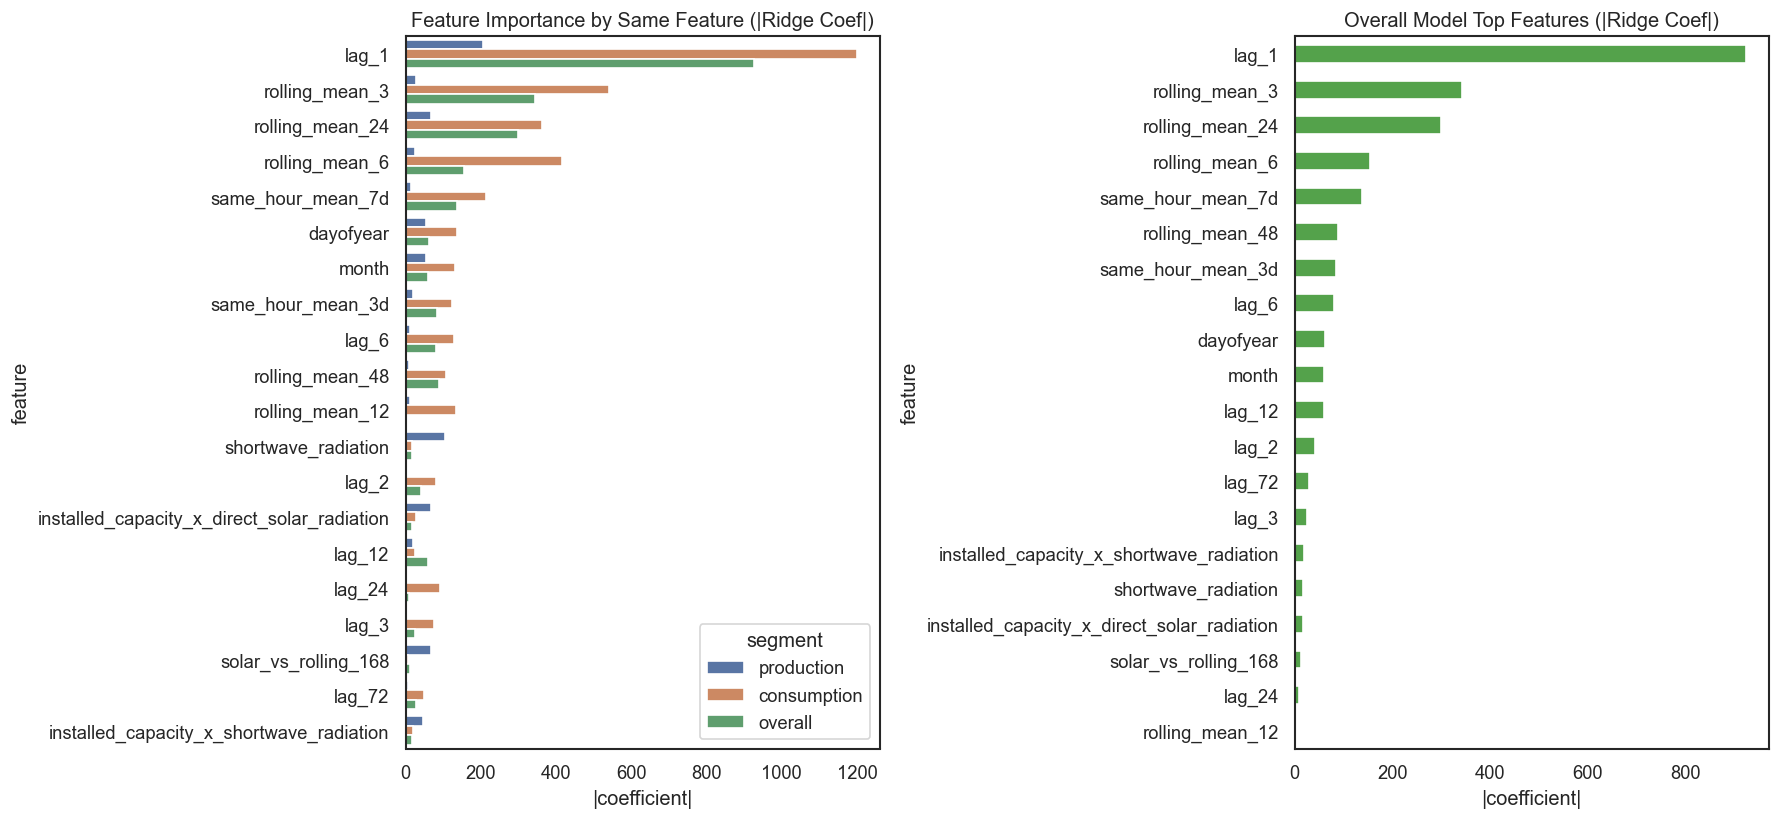

In [30]:
# 5) Feature Importance (same features aligned)
fig5, axes = plt.subplots(1, 2, figsize=(15, 7))

plot_df = (
    coef_compare_top[["production", "consumption", "overall"]]
    .reset_index()
    .rename(columns={"index": "feature"})
    .melt(id_vars="feature", var_name="segment", value_name="abs_coef")
)

sns.barplot(
    data=plot_df,
    y="feature",
    x="abs_coef",
    hue="segment",
    orient="h",
    ax=axes[0],
)
axes[0].set_title("Feature Importance by Same Feature (|Ridge Coef|)")
axes[0].set_xlabel("|coefficient|")
axes[0].set_ylabel("feature")
axes[0].legend(title="segment")

coef_compare_top["overall"].sort_values().plot(kind="barh", ax=axes[1], color=COLOR_OVERALL)
axes[1].set_title("Overall Model Top Features (|Ridge Coef|)")
axes[1].set_xlabel("|coefficient|")
axes[1].set_ylabel("feature")

plt.tight_layout()
figures.append(fig5)
figure_names.append("05_feature_importance_same_feature_ridge.jpg")
plt.show()

In [31]:
saved_paths = []
for fig, name in zip(figures, figure_names):
    out = FIG_DIR / name
    fig.savefig(out, dpi=150, bbox_inches="tight", format="jpg")
    saved_paths.append(out)

print("Saved figure files:")
for p in saved_paths:
    print(p)

Saved figure files:
/Users/gang-gyeonglim/Desktop/DataScience2026/notebooks/Rigde_codex_figures/01_ridge_mae_summary.jpg
/Users/gang-gyeonglim/Desktop/DataScience2026/notebooks/Rigde_codex_figures/02_rolling_feature_mae.jpg
/Users/gang-gyeonglim/Desktop/DataScience2026/notebooks/Rigde_codex_figures/03_lag_mae.jpg
/Users/gang-gyeonglim/Desktop/DataScience2026/notebooks/Rigde_codex_figures/04_residual_analysis_ridge.jpg
/Users/gang-gyeonglim/Desktop/DataScience2026/notebooks/Rigde_codex_figures/05_feature_importance_same_feature_ridge.jpg
